# 13. Politica Hibrida y Conservadora de Clipping Thoracolumbar - Colab

Este notebook no entrena un modelo nuevo. Su objetivo es convertir lo aprendido
en los notebooks `11` y `12` en una **regla operativa mas segura** para el
pipeline final.

## Contexto

- el baseline `last_visible_pred_clip` fue la mejor variante validada del pipeline
- el reentrenamiento refinado del notebook `12` mejoro metricas intermedias del
  estimador `last_visible`
- pero ese refinamiento empeoro la metrica final de segmentacion porque aumento
  los `missing labels`

## Pregunta que responde este notebook

> Podemos usar el refinado de forma selectiva, solo en los casos donde parece
> seguro, y conservar el baseline o incluso `raw` en los demas?

## Enfoque

Construimos y comparamos varias politicas candidatas usando solo senales
disponibles en inferencia:

- `trim_baseline`
- `trim_refined`
- diferencia entre `last_pred_idx` de baseline y refined
- tipo de muestra (`Normal` o `Scoliosis`)
- cobertura parcial o completa

La evaluacion principal en este notebook es **proxy a nivel de set de etiquetas**.
Esto nos permite seleccionar una politica prometedora antes de llevarla a una
integracion final del pipeline.

## 0. Preparacion de Colab

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work")
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"No existe la carpeta: {PROJECT_ROOT}")

os.chdir(PROJECT_ROOT)
print("Working directory:", Path.cwd())


Mounted at /content/drive
Working directory: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work


## 1. Librerias y rutas

Este notebook trabaja sobre los artefactos ya generados por:

- `07`: baseline de `last_visible`
- `10`: hard case mining y sampling refinado
- `12`: reentrenamiento refinado

In [2]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / 'analysis_outputs' / 'hybrid_conservative_clipping_policy_thoracolumbar_tuned'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def resolve_existing(*relative_candidates: str) -> Path:
    search_roots = [ROOT, ROOT / 'data' / 'ScoliosisDataSetYeisson', ROOT / 'data', ROOT / 'reports']
    for base in search_roots:
        for rel in relative_candidates:
            candidate = base / rel
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f'No se encontro ninguno de estos archivos: {relative_candidates}')


MANIFEST_PATH = resolve_existing('analysis_outputs/training_manifest_thoracolumbar.csv')
BASELINE_SUMMARY_PATH = resolve_existing(
    'analysis_outputs/last_visible_estimator_thoracolumbar_explained_tuned/last_visible_experiment_summary.csv'
)
BASELINE_COMPARE_PATH = resolve_existing(
    'analysis_outputs/last_visible_estimator_thoracolumbar_explained_tuned/last_visible_per_sample_compare.csv'
)
BASELINE_TEST_PATH = resolve_existing(
    'analysis_outputs/last_visible_estimator_thoracolumbar_explained_tuned/last_visible_test_predictions.csv'
)
REFINED_SUMMARY_PATH = resolve_existing(
    'analysis_outputs/last_visible_estimator_thoracolumbar_refined_explained_tuned/last_visible_refined_experiment_summary.csv'
)
REFINED_COMPARE_PATH = resolve_existing(
    'analysis_outputs/last_visible_estimator_thoracolumbar_refined_explained_tuned/last_visible_per_sample_compare.csv'
)
REFINED_TEST_PATH = resolve_existing(
    'analysis_outputs/last_visible_estimator_thoracolumbar_refined_explained_tuned/last_visible_test_predictions.csv'
)

print('OUTPUT_DIR:', OUTPUT_DIR)


OUTPUT_DIR: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/hybrid_conservative_clipping_policy_thoracolumbar_tuned


## 2. Carga y normalizacion de tablas

Unificamos baseline y refined a nivel de muestra para poder evaluar politicas.

In [3]:
manifest_df = pd.read_csv(MANIFEST_PATH)
baseline_summary_df = pd.read_csv(BASELINE_SUMMARY_PATH)
baseline_compare_df = pd.read_csv(BASELINE_COMPARE_PATH)
baseline_test_df = pd.read_csv(BASELINE_TEST_PATH)
refined_summary_df = pd.read_csv(REFINED_SUMMARY_PATH)
refined_compare_df = pd.read_csv(REFINED_COMPARE_PATH)
refined_test_df = pd.read_csv(REFINED_TEST_PATH)


def count_labels(text: object) -> int:
    if pd.isna(text):
        return 0
    return len([item.strip() for item in str(text).split(',') if item.strip()])


baseline_compare_df = baseline_compare_df.rename(
    columns={
        'last_pred_label': 'baseline_last_pred_label',
        'last_pred_clip_labels': 'baseline_clip_labels',
        'last_extra_count': 'baseline_extra_count',
        'last_missing_count': 'baseline_missing_count',
        'raw_extra_count': 'raw_extra_count',
        'raw_missing_count': 'raw_missing_count',
        'raw_labels': 'raw_labels',
        'gt_labels': 'gt_labels',
        'split': 'split',
        'image': 'image',
    }
)
baseline_test_df = baseline_test_df.rename(
    columns={
        'last_pred_idx': 'baseline_last_pred_idx',
        'last_abs_error': 'baseline_last_abs_error',
        'last_exact_match': 'baseline_last_exact_match',
        'last_within1_match': 'baseline_last_within1_match',
        'last_overprediction': 'baseline_last_overprediction',
        'last_underprediction': 'baseline_last_underprediction',
    }
)

refined_compare_df = refined_compare_df.rename(
    columns={
        'last_pred_label': 'refined_last_pred_label',
        'last_pred_clip_labels': 'refined_clip_labels',
        'last_extra_count': 'refined_extra_count',
        'last_missing_count': 'refined_missing_count',
    }
)
refined_test_df = refined_test_df.rename(
    columns={
        'last_pred_idx': 'refined_last_pred_idx',
        'last_abs_error': 'refined_last_abs_error',
        'last_exact_match': 'refined_last_exact_match',
        'last_within1_match': 'refined_last_within1_match',
        'last_overprediction': 'refined_last_overprediction',
        'last_underprediction': 'refined_last_underprediction',
    }
)

manifest_subset_df = manifest_df[
    [
        'unique_sample_id', 'num_visible_target_vertebrae', 'last_visible_target',
        'total_internal_missing_count', 'split', 'image'
    ]
].drop_duplicates()

compare_df = (
    baseline_compare_df[
        [
            'unique_sample_id', 'split', 'image', 'gt_labels', 'raw_labels',
            'baseline_clip_labels', 'raw_extra_count', 'raw_missing_count',
            'baseline_extra_count', 'baseline_missing_count'
        ]
    ]
    .merge(
        baseline_test_df[
            [
                'unique_sample_id', 'first_idx', 'last_true_idx',
                'baseline_last_pred_idx', 'baseline_last_abs_error',
                'baseline_last_exact_match', 'baseline_last_within1_match',
                'baseline_last_overprediction', 'baseline_last_underprediction'
            ]
        ],
        on='unique_sample_id',
        how='left',
    )
    .merge(
        refined_compare_df[
            ['unique_sample_id', 'refined_clip_labels', 'refined_extra_count', 'refined_missing_count']
        ],
        on='unique_sample_id',
        how='left',
    )
    .merge(
        refined_test_df[
            [
                'unique_sample_id', 'refined_last_pred_idx', 'refined_last_abs_error',
                'refined_last_exact_match', 'refined_last_within1_match',
                'refined_last_overprediction', 'refined_last_underprediction'
            ]
        ],
        on='unique_sample_id',
        how='left',
    )
    .merge(
        manifest_subset_df.rename(columns={'split': 'manifest_split', 'image': 'manifest_image'}),
        on='unique_sample_id',
        how='left',
    )
)

if 'split' not in compare_df.columns:
    compare_df['split'] = compare_df['manifest_split']
compare_df['split'] = compare_df['split'].fillna(compare_df['manifest_split'])
if 'image' not in compare_df.columns:
    compare_df['image'] = compare_df['manifest_image']
compare_df['image'] = compare_df['image'].fillna(compare_df['manifest_image'])

compare_df['raw_num_labels'] = compare_df['raw_labels'].apply(count_labels)
compare_df['baseline_num_labels'] = compare_df['baseline_clip_labels'].apply(count_labels)
compare_df['refined_num_labels'] = compare_df['refined_clip_labels'].apply(count_labels)
compare_df['trim_baseline'] = compare_df['raw_num_labels'] - compare_df['baseline_num_labels']
compare_df['trim_refined'] = compare_df['raw_num_labels'] - compare_df['refined_num_labels']
compare_df['baseline_refined_idx_gap'] = (
    compare_df['baseline_last_pred_idx'] - compare_df['refined_last_pred_idx']
).abs()
compare_df['is_partial_case'] = compare_df['num_visible_target_vertebrae'] < 17
compare_df['is_scoliosis_case'] = compare_df['split'].astype(str).str.lower().eq('scoliosis')

print('compare_df:', compare_df.shape)
display(compare_df.head())

compare_df: (45, 40)


,unique_sample_id,split,image,gt_labels,raw_labels,baseline_clip_labels,raw_extra_count,raw_missing_count,baseline_extra_count,baseline_missing_count,...,manifest_split,manifest_image,raw_num_labels,baseline_num_labels,refined_num_labels,trim_baseline,trim_refined,baseline_refined_idx_gap,is_partial_case,is_scoliosis_case
0,Normal__N_4.jpg,Normal,N_4.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",0,0,0,0,...,Normal,N_4.jpg,17,17,16,0,1,1,False,False
1,Normal__N_6.jpg,Normal,N_6.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",0,0,0,0,...,Normal,N_6.jpg,17,17,16,0,1,1,False,False
2,Normal__N_8.jpg,Normal,N_8.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",0,0,0,0,...,Normal,N_8.jpg,17,17,16,0,1,1,False,False
3,Normal__N_15.jpg,Normal,N_15.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",0,0,0,0,...,Normal,N_15.jpg,17,17,16,0,1,1,False,False
4,Normal__N_18.jpg,Normal,N_18.jpg,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",0,0,0,0,...,Normal,N_18.jpg,17,17,16,0,1,1,False,False


## 3. Contexto de baseline vs refined

Antes de buscar una politica hibrida, dejamos clara la diferencia entre ambos.

In [4]:
baseline_summary = dict(zip(baseline_summary_df['metric'], baseline_summary_df['value']))
refined_summary = dict(zip(refined_summary_df['metric'], refined_summary_df['value']))

global_context_df = pd.DataFrame([
    {
        'metric': 'last_test_exact_acc',
        'baseline': float(baseline_summary.get('last_test_exact_acc', np.nan)),
        'refined': float(refined_summary.get('last_test_exact_acc', np.nan)),
    },
    {
        'metric': 'last_test_within1_acc',
        'baseline': float(baseline_summary.get('last_test_within1_acc', np.nan)),
        'refined': float(refined_summary.get('last_test_within1_acc', np.nan)),
    },
    {
        'metric': 'last_test_mae',
        'baseline': float(baseline_summary.get('last_test_mae', np.nan)),
        'refined': float(refined_summary.get('last_test_mae', np.nan)),
    },
    {
        'metric': 'last_test_overprediction_rate',
        'baseline': float(baseline_summary.get('last_test_overprediction_rate', np.nan)),
        'refined': float(refined_summary.get('last_test_overprediction_rate', np.nan)),
    },
    {
        'metric': 'clip_macro_dice_fg',
        'baseline': float(baseline_summary.get('last_pred_clip_macro_dice_fg', np.nan)),
        'refined': float(refined_summary.get('last_pred_clip_refined_macro_dice_fg', np.nan)),
    },
    {
        'metric': 'mean_last_extra_count',
        'baseline': float(baseline_summary.get('mean_last_extra_count', np.nan)),
        'refined': float(refined_summary.get('mean_last_extra_count', np.nan)),
    },
    {
        'metric': 'mean_last_missing_count',
        'baseline': float(baseline_summary.get('mean_last_missing_count', np.nan)),
        'refined': float(refined_summary.get('mean_last_missing_count', np.nan)),
    },
])
global_context_df['delta_refined_minus_baseline'] = global_context_df['refined'] - global_context_df['baseline']
display(global_context_df)

,metric,baseline,refined,delta_refined_minus_baseline
0,last_test_exact_acc,0.422222,0.155556,-0.266667
1,last_test_within1_acc,0.577778,0.666667,0.088889
2,last_test_mae,2.000000,2.311111,0.311111
3,last_test_overprediction_rate,0.400000,0.488889,0.088889
4,clip_macro_dice_fg,0.351934,0.324826,-0.027108
5,mean_last_extra_count,1.511111,1.844444,0.333333
6,mean_last_missing_count,0.488889,0.466667,-0.022222


## 4. Proxy de calidad por set de etiquetas

Para las politicas hibridas usamos un proxy que depende de:

- `missing_count`
- `extra_count`
- cantidad de etiquetas verdaderas

Esto no reemplaza una validacion pixel a pixel, pero si es muy util para elegir
una regla prometedora con bajo riesgo.

In [5]:
def label_set_dice_proxy(num_gt: float, missing: float, extra: float) -> float:
    true_positive = max(float(num_gt) - float(missing), 0.0)
    denom = (2.0 * true_positive) + float(missing) + float(extra)
    if denom <= 0:
        return 1.0
    return (2.0 * true_positive) / denom


compare_df['num_gt_labels'] = compare_df['gt_labels'].apply(count_labels)
compare_df['raw_labelset_dice_proxy'] = compare_df.apply(
    lambda row: label_set_dice_proxy(row['num_gt_labels'], row['raw_missing_count'], row['raw_extra_count']),
    axis=1,
)
compare_df['baseline_labelset_dice_proxy'] = compare_df.apply(
    lambda row: label_set_dice_proxy(row['num_gt_labels'], row['baseline_missing_count'], row['baseline_extra_count']),
    axis=1,
)
compare_df['refined_labelset_dice_proxy'] = compare_df.apply(
    lambda row: label_set_dice_proxy(row['num_gt_labels'], row['refined_missing_count'], row['refined_extra_count']),
    axis=1,
)

display(
    compare_df[
        [
            'unique_sample_id', 'split', 'image', 'num_gt_labels', 'raw_num_labels',
            'trim_baseline', 'trim_refined', 'baseline_refined_idx_gap',
            'raw_labelset_dice_proxy', 'baseline_labelset_dice_proxy', 'refined_labelset_dice_proxy'
        ]
    ].head(15)
)

,unique_sample_id,split,image,num_gt_labels,raw_num_labels,trim_baseline,trim_refined,baseline_refined_idx_gap,raw_labelset_dice_proxy,baseline_labelset_dice_proxy,refined_labelset_dice_proxy
0,Normal__N_4.jpg,Normal,N_4.jpg,17,17,0,1,1,1.000000,1.000000,0.969697
1,Normal__N_6.jpg,Normal,N_6.jpg,17,17,0,1,1,1.000000,1.000000,0.969697
2,Normal__N_8.jpg,Normal,N_8.jpg,17,17,0,1,1,1.000000,1.000000,0.969697
3,Normal__N_15.jpg,Normal,N_15.jpg,17,17,0,1,1,1.000000,1.000000,0.969697
4,Normal__N_18.jpg,Normal,N_18.jpg,17,17,0,1,1,1.000000,1.000000,0.969697
5,Normal__N_19.jpg,Normal,N_19.jpg,17,17,0,1,1,1.000000,1.000000,0.969697
6,Normal__N_23.jpg,Normal,N_23.jpg,16,17,0,0,0,0.969697,0.969697,0.969697
7,Normal__N_24.jpg,Normal,N_24.jpg,17,17,0,1,1,1.000000,1.000000,0.969697
8,Normal__N_26.jpg,Normal,N_26.jpg,15,17,0,1,1,0.937500,0.937500,0.967742
9,Normal__N_27.jpg,Normal,N_27.jpg,14,17,0,1,1,0.903226,0.903226,0.933333


## 5. Politicas candidatas

Todas las politicas usan solo informacion disponible en inferencia.

Opciones:

- `raw_only`
- `baseline_always`
- `refined_always`
- `baseline_if_trim_ge_k`
- politicas hibridas donde `refined` solo entra cuando:
  - recorta de forma moderada
  - no discrepa mucho del baseline

In [6]:
def choose_policy_output(row: pd.Series, policy_name: str) -> str:
    trim_b = float(row['trim_baseline'])
    trim_r = float(row['trim_refined'])
    gap = float(row['baseline_refined_idx_gap'])
    is_scoliosis = bool(row['is_scoliosis_case'])

    if policy_name == 'raw_only':
        return 'raw'
    if policy_name == 'baseline_always':
        return 'baseline'
    if policy_name == 'refined_always':
        return 'refined'
    if policy_name == 'baseline_if_trim_ge_1_else_raw':
        return 'baseline' if trim_b >= 1 else 'raw'
    if policy_name == 'baseline_if_trim_ge_2_else_raw':
        return 'baseline' if trim_b >= 2 else 'raw'
    if policy_name == 'baseline_if_trim_ge_3_else_raw':
        return 'baseline' if trim_b >= 3 else 'raw'
    if policy_name == 'refined_if_trim_ge_1_else_raw':
        return 'refined' if trim_r >= 1 else 'raw'
    if policy_name == 'refined_if_trim_ge_2_else_raw':
        return 'refined' if trim_r >= 2 else 'raw'
    if policy_name == 'hybrid_refined_if_trim_ge_1_and_gap_le_1_else_baseline_if_trim_ge_1_else_raw':
        if trim_r >= 1 and gap <= 1:
            return 'refined'
        if trim_b >= 1:
            return 'baseline'
        return 'raw'
    if policy_name == 'hybrid_refined_if_trim_ge_2_and_gap_le_1_else_baseline_if_trim_ge_1_else_raw':
        if trim_r >= 2 and gap <= 1:
            return 'refined'
        if trim_b >= 1:
            return 'baseline'
        return 'raw'
    if policy_name == 'hybrid_raw_if_gap_ge_3_else_baseline_if_trim_ge_1_else_refined_if_trim_ge_1':
        if gap >= 3:
            return 'raw'
        if trim_b >= 1:
            return 'baseline'
        if trim_r >= 1:
            return 'refined'
        return 'raw'
    if policy_name == 'hybrid_scoliosis_baseline_else_refined_if_trim_ge_2_and_gap_le_1_else_raw':
        if is_scoliosis:
            return 'baseline' if trim_b >= 1 else 'raw'
        if trim_r >= 2 and gap <= 1:
            return 'refined'
        return 'raw'
    raise ValueError(f'Politica no soportada: {policy_name}')


candidate_policies = [
    'raw_only',
    'baseline_always',
    'refined_always',
    'baseline_if_trim_ge_1_else_raw',
    'baseline_if_trim_ge_2_else_raw',
    'baseline_if_trim_ge_3_else_raw',
    'refined_if_trim_ge_1_else_raw',
    'refined_if_trim_ge_2_else_raw',
    'hybrid_refined_if_trim_ge_1_and_gap_le_1_else_baseline_if_trim_ge_1_else_raw',
    'hybrid_refined_if_trim_ge_2_and_gap_le_1_else_baseline_if_trim_ge_1_else_raw',
    'hybrid_raw_if_gap_ge_3_else_baseline_if_trim_ge_1_else_refined_if_trim_ge_1',
    'hybrid_scoliosis_baseline_else_refined_if_trim_ge_2_and_gap_le_1_else_raw',
]

for policy_name in candidate_policies:
    compare_df[policy_name] = compare_df.apply(lambda row: choose_policy_output(row, policy_name), axis=1)

display(compare_df[['unique_sample_id', 'split', 'image'] + candidate_policies[:6]].head(12))

,unique_sample_id,split,image,raw_only,baseline_always,refined_always,baseline_if_trim_ge_1_else_raw,baseline_if_trim_ge_2_else_raw,baseline_if_trim_ge_3_else_raw
0,Normal__N_4.jpg,Normal,N_4.jpg,raw,baseline,refined,raw,raw,raw
1,Normal__N_6.jpg,Normal,N_6.jpg,raw,baseline,refined,raw,raw,raw
2,Normal__N_8.jpg,Normal,N_8.jpg,raw,baseline,refined,raw,raw,raw
3,Normal__N_15.jpg,Normal,N_15.jpg,raw,baseline,refined,raw,raw,raw
4,Normal__N_18.jpg,Normal,N_18.jpg,raw,baseline,refined,raw,raw,raw
5,Normal__N_19.jpg,Normal,N_19.jpg,raw,baseline,refined,raw,raw,raw
6,Normal__N_23.jpg,Normal,N_23.jpg,raw,baseline,refined,raw,raw,raw
7,Normal__N_24.jpg,Normal,N_24.jpg,raw,baseline,refined,raw,raw,raw
8,Normal__N_26.jpg,Normal,N_26.jpg,raw,baseline,refined,raw,raw,raw
9,Normal__N_27.jpg,Normal,N_27.jpg,raw,baseline,refined,raw,raw,raw


## 6. Evaluacion de politicas

El criterio principal es:

1. mayor `mean_proxy_dice`
2. menor `mean_missing_count`
3. menor `mean_extra_count`

Damos mas prioridad a no destruir vertebras correctas que a reducir extras de
forma agresiva.

In [7]:
def summarize_policy(df: pd.DataFrame, choice_col: str, policy_name: str) -> dict:
    selected_missing = np.where(
        df[choice_col] == 'baseline',
        df['baseline_missing_count'],
        np.where(df[choice_col] == 'refined', df['refined_missing_count'], df['raw_missing_count']),
    )
    selected_extra = np.where(
        df[choice_col] == 'baseline',
        df['baseline_extra_count'],
        np.where(df[choice_col] == 'refined', df['refined_extra_count'], df['raw_extra_count']),
    )
    selected_proxy = np.where(
        df[choice_col] == 'baseline',
        df['baseline_labelset_dice_proxy'],
        np.where(df[choice_col] == 'refined', df['refined_labelset_dice_proxy'], df['raw_labelset_dice_proxy']),
    )
    use_raw = np.mean(df[choice_col] == 'raw')
    use_baseline = np.mean(df[choice_col] == 'baseline')
    use_refined = np.mean(df[choice_col] == 'refined')
    clean_improvement = (
        (selected_extra < df['raw_extra_count'])
        & (selected_missing <= df['raw_missing_count'])
    ).mean()
    harm_rate = (selected_missing > df['raw_missing_count']).mean()
    return {
        'policy_name': policy_name,
        'mean_proxy_dice': float(np.mean(selected_proxy)),
        'mean_missing_count': float(np.mean(selected_missing)),
        'mean_extra_count': float(np.mean(selected_extra)),
        'fraction_raw': float(use_raw),
        'fraction_baseline': float(use_baseline),
        'fraction_refined': float(use_refined),
        'clean_improvement_rate': float(clean_improvement),
        'harm_rate': float(harm_rate),
    }


policy_rows = []
for policy_name in candidate_policies:
    policy_rows.append(summarize_policy(compare_df, policy_name, policy_name))

policy_compare_df = pd.DataFrame(policy_rows).sort_values(
    ['mean_proxy_dice', 'mean_missing_count', 'mean_extra_count'],
    ascending=[False, True, True],
).reset_index(drop=True)

display(policy_compare_df)

,policy_name,mean_proxy_dice,mean_missing_count,mean_extra_count,fraction_raw,fraction_baseline,fraction_refined,clean_improvement_rate,harm_rate
0,hybrid_scoliosis_baseline_else_refined_if_trim...,0.925374,0.333333,1.511111,0.533333,0.466667,0.000000,0.311111,0.155556
1,baseline_always,0.919613,0.488889,1.511111,0.000000,1.000000,0.000000,0.311111,0.177778
2,baseline_if_trim_ge_1_else_raw,0.919613,0.488889,1.511111,0.511111,0.488889,0.000000,0.311111,0.177778
3,baseline_if_trim_ge_2_else_raw,0.917549,0.488889,1.577778,0.577778,0.422222,0.000000,0.244444,0.177778
4,hybrid_refined_if_trim_ge_2_and_gap_le_1_else_...,0.915520,0.511111,1.600000,0.511111,0.355556,0.133333,0.288889,0.200000
5,hybrid_refined_if_trim_ge_1_and_gap_le_1_else_...,0.914211,0.688889,1.466667,0.088889,0.222222,0.688889,0.533333,0.377778
6,baseline_if_trim_ge_3_else_raw,0.913755,0.422222,1.777778,0.711111,0.288889,0.000000,0.177778,0.111111
7,refined_always,0.909406,0.466667,1.844444,0.000000,0.000000,1.000000,0.533333,0.355556
8,refined_if_trim_ge_1_else_raw,0.909406,0.466667,1.844444,0.111111,0.000000,0.888889,0.533333,0.355556
9,hybrid_raw_if_gap_ge_3_else_baseline_if_trim_g...,0.908980,0.377778,2.000000,0.244444,0.333333,0.422222,0.422222,0.333333


## 7. Comparacion por slices para la mejor politica

In [8]:
best_policy_name = policy_compare_df.iloc[0]['policy_name']

slice_rows = []
slice_specs = [
    ('all_test', pd.Series([True] * len(compare_df))),
    ('partial', compare_df['is_partial_case']),
    ('full_range', ~compare_df['is_partial_case']),
    ('scoliosis', compare_df['is_scoliosis_case']),
    ('normal', ~compare_df['is_scoliosis_case']),
]

for slice_name, mask in slice_specs:
    work = compare_df.loc[mask.fillna(False)].copy()
    if work.empty:
        continue

    selected_missing = np.where(
        work[best_policy_name] == 'baseline',
        work['baseline_missing_count'],
        np.where(work[best_policy_name] == 'refined', work['refined_missing_count'], work['raw_missing_count']),
    )
    selected_extra = np.where(
        work[best_policy_name] == 'baseline',
        work['baseline_extra_count'],
        np.where(work[best_policy_name] == 'refined', work['refined_extra_count'], work['raw_extra_count']),
    )
    selected_proxy = np.where(
        work[best_policy_name] == 'baseline',
        work['baseline_labelset_dice_proxy'],
        np.where(work[best_policy_name] == 'refined', work['refined_labelset_dice_proxy'], work['raw_labelset_dice_proxy']),
    )

    slice_rows.append({
        'slice_name': slice_name,
        'images': len(work),
        'mean_proxy_dice': float(np.mean(selected_proxy)),
        'mean_missing_count': float(np.mean(selected_missing)),
        'mean_extra_count': float(np.mean(selected_extra)),
        'fraction_raw': float(np.mean(work[best_policy_name] == 'raw')),
        'fraction_baseline': float(np.mean(work[best_policy_name] == 'baseline')),
        'fraction_refined': float(np.mean(work[best_policy_name] == 'refined')),
    })

best_policy_slice_df = pd.DataFrame(slice_rows)
display(best_policy_slice_df)

,slice_name,images,mean_proxy_dice,mean_missing_count,mean_extra_count,fraction_raw,fraction_baseline,fraction_refined
0,all_test,45,0.925374,0.333333,1.511111,0.533333,0.466667,0.0
1,partial,32,0.895057,0.468750,2.125000,0.343750,0.656250,0.0
2,full_range,13,1.000000,0.000000,0.000000,1.000000,0.000000,0.0
3,scoliosis,28,0.894489,0.535714,2.000000,0.250000,0.750000,0.0
4,normal,17,0.976243,0.000000,0.705882,1.000000,0.000000,0.0


## 8. Casos donde refined parece util

Esta tabla es importante para la interpretacion final: nos muestra si el modelo
refinado tiene una zona util de aplicacion, aunque no deba usarse siempre.

In [9]:
refined_win_df = compare_df.loc[
    (compare_df['refined_labelset_dice_proxy'] > compare_df['baseline_labelset_dice_proxy'])
    & (compare_df['refined_missing_count'] <= compare_df['baseline_missing_count'])
].copy()

refined_win_df = refined_win_df.sort_values(
    ['refined_labelset_dice_proxy', 'baseline_refined_idx_gap', 'trim_refined'],
    ascending=[False, True, False],
)

display(
    refined_win_df[
        [
            'unique_sample_id', 'split', 'image', 'num_visible_target_vertebrae',
            'baseline_last_pred_idx', 'refined_last_pred_idx', 'baseline_refined_idx_gap',
            'trim_baseline', 'trim_refined',
            'baseline_labelset_dice_proxy', 'refined_labelset_dice_proxy',
            'baseline_missing_count', 'refined_missing_count',
            'baseline_extra_count', 'refined_extra_count',
        ]
    ].head(25)
)

,unique_sample_id,split,image,num_visible_target_vertebrae,baseline_last_pred_idx,refined_last_pred_idx,baseline_refined_idx_gap,trim_baseline,trim_refined,baseline_labelset_dice_proxy,refined_labelset_dice_proxy,baseline_missing_count,refined_missing_count,baseline_extra_count,refined_extra_count
23,Scoliosis__S_44.jpg,Scoliosis,S_44.jpg,16,14,15,1,2,1,0.967742,1.000000,1,0,0,0
35,Scoliosis__S_136.jpg,Scoliosis,S_136.jpg,16,14,15,1,2,1,0.967742,1.000000,1,0,0,0
36,Scoliosis__S_140.jpg,Scoliosis,S_140.jpg,16,14,15,1,2,1,0.967742,1.000000,1,0,0,0
38,Scoliosis__S_144.jpg,Scoliosis,S_144.jpg,16,16,15,1,0,1,0.969697,1.000000,0,0,1,0
40,Scoliosis__S_152.jpg,Scoliosis,S_152.jpg,13,9,12,3,7,4,0.869565,1.000000,3,0,0,0
11,Normal__N_32.jpg,Normal,N_32.jpg,17,9,15,6,7,1,0.740741,0.969697,7,1,0,0
8,Normal__N_26.jpg,Normal,N_26.jpg,15,16,15,1,0,1,0.937500,0.967742,0,0,2,1
34,Scoliosis__S_129.jpg,Scoliosis,S_129.jpg,15,16,15,1,0,1,0.937500,0.967742,0,0,2,1
44,Scoliosis__S_193.jpg,Scoliosis,S_193.jpg,14,9,12,3,7,4,0.833333,0.962963,4,1,0,0
19,Scoliosis__S_25.jpg,Scoliosis,S_25.jpg,12,9,12,3,7,4,0.909091,0.960000,2,0,0,1


## 9. Recomendacion operativa

Este notebook no declara automaticamente que la mejor politica proxy se vuelva
politica final del proyecto. Primero deja una recomendacion razonada.

In [10]:
best_row = policy_compare_df.iloc[0]
baseline_row = policy_compare_df.loc[policy_compare_df['policy_name'] == 'baseline_always'].iloc[0]
raw_row = policy_compare_df.loc[policy_compare_df['policy_name'] == 'raw_only'].iloc[0]

recommendation_rows = [
    {
        'decision_type': 'best_proxy_policy',
        'recommended_policy': best_row['policy_name'],
        'reason': 'Es la politica con mejor balance proxy entre calidad, missing y extra labels.',
        'reference_value': float(best_row['mean_proxy_dice']),
    },
    {
        'decision_type': 'baseline_reference_policy',
        'recommended_policy': baseline_row['policy_name'],
        'reason': 'Es la politica operativa actual mas fuerte del proyecto.',
        'reference_value': float(baseline_row['mean_proxy_dice']),
    },
    {
        'decision_type': 'raw_reference_policy',
        'recommended_policy': raw_row['policy_name'],
        'reason': 'Sirve como control de no-clipping.',
        'reference_value': float(raw_row['mean_proxy_dice']),
    },
]

recommendation_df = pd.DataFrame(recommendation_rows)
display(recommendation_df)

,decision_type,recommended_policy,reason,reference_value
0,best_proxy_policy,hybrid_scoliosis_baseline_else_refined_if_trim...,Es la politica con mejor balance proxy entre c...,0.925374
1,baseline_reference_policy,baseline_always,Es la politica operativa actual mas fuerte del...,0.919613
2,raw_reference_policy,raw_only,Sirve como control de no-clipping.,0.888215


## 10. Visualizaciones

/tmp/ipykernel_1113/1236695785.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


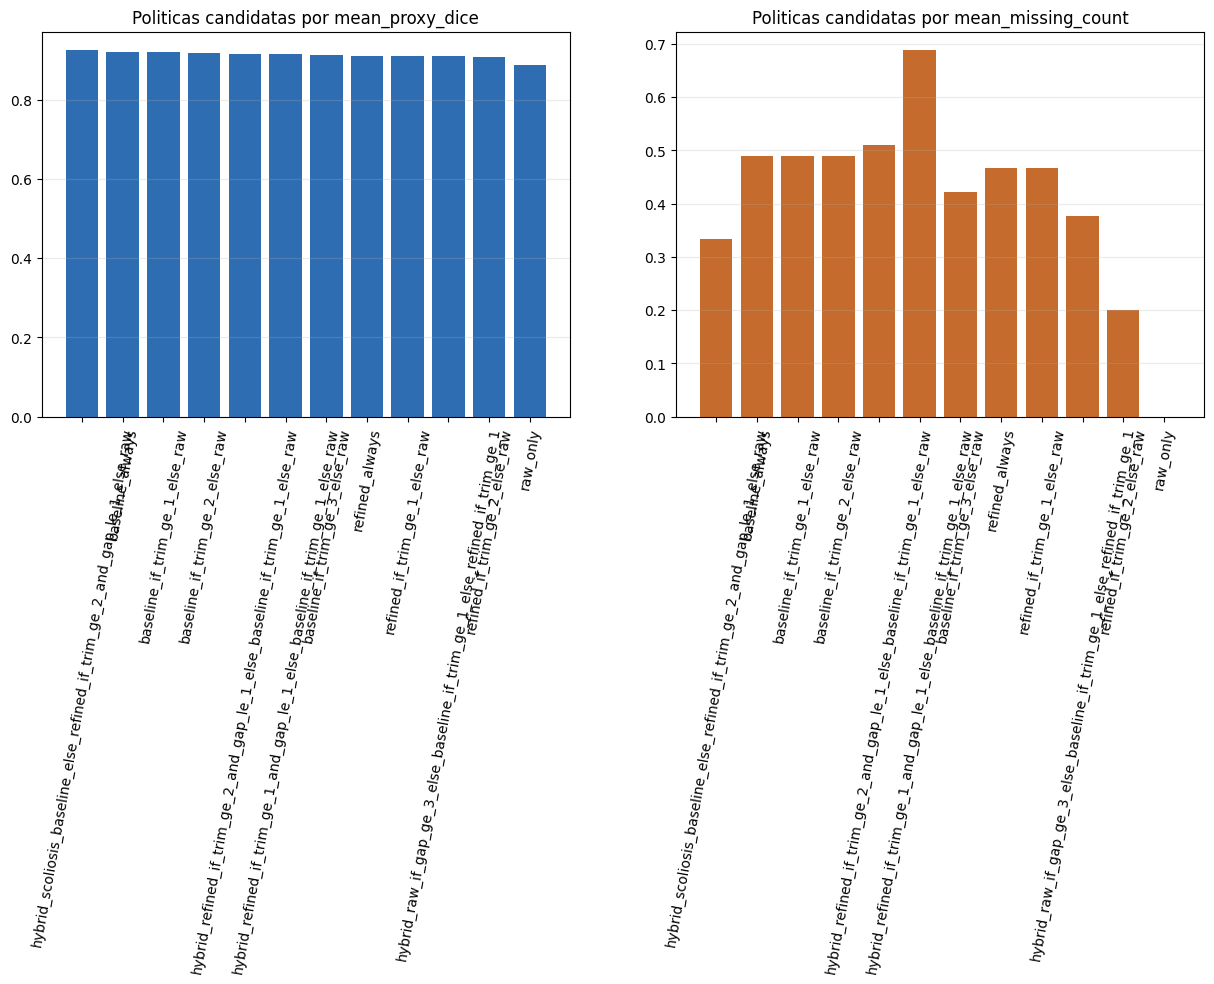

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(policy_compare_df['policy_name'], policy_compare_df['mean_proxy_dice'], color='#2f6db3')
axes[0].set_title('Politicas candidatas por mean_proxy_dice')
axes[0].tick_params(axis='x', rotation=80)
axes[0].grid(alpha=0.25, axis='y')

axes[1].bar(policy_compare_df['policy_name'], policy_compare_df['mean_missing_count'], color='#c46b2d')
axes[1].set_title('Politicas candidatas por mean_missing_count')
axes[1].tick_params(axis='x', rotation=80)
axes[1].grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.show()

## 11. Exportacion

In [12]:
context_path = OUTPUT_DIR / 'baseline_vs_refined_context.csv'
merged_compare_path = OUTPUT_DIR / 'hybrid_policy_merged_compare.csv'
policy_compare_path = OUTPUT_DIR / 'hybrid_policy_compare.csv'
slice_path = OUTPUT_DIR / 'hybrid_policy_best_slice_summary.csv'
refined_win_path = OUTPUT_DIR / 'hybrid_policy_refined_useful_cases.csv'
recommendation_path = OUTPUT_DIR / 'hybrid_policy_recommendation.csv'

global_context_df.to_csv(context_path, index=False)
compare_df.to_csv(merged_compare_path, index=False)
policy_compare_df.to_csv(policy_compare_path, index=False)
best_policy_slice_df.to_csv(slice_path, index=False)
refined_win_df.to_csv(refined_win_path, index=False)
recommendation_df.to_csv(recommendation_path, index=False)

print('Guardado:', context_path)
print('Guardado:', merged_compare_path)
print('Guardado:', policy_compare_path)
print('Guardado:', slice_path)
print('Guardado:', refined_win_path)
print('Guardado:', recommendation_path)

Guardado: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/hybrid_conservative_clipping_policy_thoracolumbar_tuned/baseline_vs_refined_context.csv
Guardado: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/hybrid_conservative_clipping_policy_thoracolumbar_tuned/hybrid_policy_merged_compare.csv
Guardado: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/hybrid_conservative_clipping_policy_thoracolumbar_tuned/hybrid_policy_compare.csv
Guardado: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/hybrid_conservative_clipping_policy_thoracolumbar_tuned/hybrid_policy_best_slice_summary.csv
Guardado: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation-Yeisson-work/analysis_outputs/hybrid_conservative_clipping_policy_thoracolumbar_tuned/hybrid_policy_refined_useful_cases.csv
Guardado: /content/drive/Othercom